# Figure 1(Difficulty)

1. Load Difficulty Result for python 

In [1]:
d_viz_target = input("INPUT 'visualization_target for difficulty RUN_ID'(e.g., run_id_111110000): ")

print(f'Figure will be drawn based on the {d_viz_target} dataset')

Figure will be drawn based on the run_id_111110000 dataset


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import os
from glob import glob

from setting_for_sdm.path_setting import path_list
from setting_for_sdm.date_setting import Date_Setting

import lib.annotation.tools.Result_Prep as rp

import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from matplotlib import pyplot as plt
import matplotlib as mpl
import lib.visualization.plot_generator as PlotGen
import lib.visualization.figure_setting as figure_setting

mpl.rcParams.update(figure_setting.fig_setting)




In [3]:
viz_dir = f'{path_list["data_root_dir"]}/result/annotate_difficulty/{d_viz_target}'
data_dir = f"{viz_dir}/data/csv"
option_dict = load_json(f"{viz_dir}/option.json")
output_dir = create_dir('./fig/')
date_range = 'Weekly'

In [4]:
path = f"{viz_dir}/{option_dict['operation_option']['llm_model']}"
file_list = os.listdir(path)
ver_list = sorted([y for y in [x for x in file_list if x.isdigit()]])


In [5]:
max(ver_list)

'111113677'

In [6]:
r_p = rp.Result_Prep()
tot_calc = pd.DataFrame()
for listid in ver_list:
    df = r_p.make_one_file(listid, path)
    if isinstance(df, pd.core.frame.DataFrame):
        # df = r_p.pp_df(df, 5)
        # df = r_p.calc_rate_byweek(df)
        tot_calc = pd.concat([tot_calc, df], axis = 0)

    

In [7]:
tmp = load_df('/mnt/hdd/mghan/so_data_availability/result/tag/run_id_100/data', ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])

    

100%|██████████| 153/153 [00:06<00:00, 23.67it/s]


In [8]:
df = tot_calc[['creationdate', 'id', 'result']].drop_duplicates()

In [9]:
ids = (
    (df.groupby('id')['result'].count() == 1)
    .reset_index(name='is_one')
    .query('is_one == True')['id']
)

In [10]:
tot_calc[tot_calc['id'] ==65102390]

,ver,creationdate,id,result
10,111110031,2020-12-02,65102390,<Difficulty Level>1
11,111110031,2020-12-02,65102390,<Difficulty Level>2
12,111110031,2020-12-02,65102390,<Difficulty Level>2
13,111110031,2020-12-02,65102390,<Difficulty Level>2
14,111110031,2020-12-02,65102390,<Difficulty Level>2
0,111111857,2020-12-02,65102390,<Difficulty Level>1
1,111111857,2020-12-02,65102390,<Difficulty Level>1
2,111111857,2020-12-02,65102390,<Difficulty Level>1
3,111111857,2020-12-02,65102390,<Difficulty Level>2
4,111111857,2020-12-02,65102390,<Difficulty Level>2


In [11]:
65102390

65102390

In [12]:
len(df['id'].unique())

54337

In [13]:
len(ids)

35201

In [14]:
tag_tmp = tmp[tmp['id'].isin(ids)]

In [15]:
tag_tmp

,cdate,id,tag,cnt,tot_cnt,pct
158,2021-06-08,67891947,pandas,1,3,0.333333
159,2021-06-08,67891947,python-requests,1,3,0.333333
160,2021-06-08,67891947,edamam-api,1,3,0.333333
231,2021-06-08,67892569,pandas,1,3,0.333333
232,2021-06-08,67892569,dataframe,1,3,0.333333
...,...,...,...,...,...,...
1525297,2024-03-28,78240245,c++,1,2,0.500000
1525298,2024-03-28,78240245,pybind11,1,2,0.500000
1525354,2024-03-28,78240764,variables,1,3,0.333333
1525355,2024-03-28,78240764,calculator,1,3,0.333333


In [16]:
tag_list = list(tag_tmp[tag_tmp['cdate'] < "2022-11-30"].groupby(['tag'])['pct'].sum().reset_index().sort_values(by = ['pct'], ascending=False)['tag'])

In [17]:
af_list = list(tag_tmp[tag_tmp['cdate'] >= "2022-11-30"].groupby(['tag'])['pct'].sum().reset_index().sort_values(by = ['pct'], ascending=False)['tag'])

In [18]:
topic_num = int(len(tag_list)*0.2)

In [19]:
af_topic_num = int(len(af_list)*0.2)

In [20]:
top_list = tag_list[:topic_num]

In [21]:
bot_list = tag_list[-topic_num : ]

In [22]:
mid_list = tag_list[topic_num : -topic_num]

In [79]:
tt = pd.DataFrame(tag_list, columns = ['tag'])

In [85]:
tt = tag_tmp[tag_tmp['cdate'] < "2022-11-30"].groupby(['tag'])['pct'].sum().reset_index().sort_values(by = ['pct'], ascending=False)

In [88]:
tt[tt['tag'] == 'openai-api']

,tag,pct
2224,openai-api,1.083333


In [24]:
len(np.setdiff1d(top_list, af_list[:af_topic_num]))

122

In [25]:
len(np.setdiff1d(bot_list, af_list[-af_topic_num:]))

711

In [26]:
result_df = pd.merge(tag_tmp, df, on = 'id', how = 'inner')

In [27]:
result_df

,cdate,id,tag,cnt,tot_cnt,pct,creationdate,result
0,2021-06-08,67891947,pandas,1,3,0.333333,2021-06-08,<Difficulty Level>0
1,2021-06-08,67891947,python-requests,1,3,0.333333,2021-06-08,<Difficulty Level>0
2,2021-06-08,67891947,edamam-api,1,3,0.333333,2021-06-08,<Difficulty Level>0
3,2021-06-08,67892569,pandas,1,3,0.333333,2021-06-08,<Difficulty Level>1
4,2021-06-08,67892569,dataframe,1,3,0.333333,2021-06-08,<Difficulty Level>1
...,...,...,...,...,...,...,...,...
78425,2024-03-28,78240245,c++,1,2,0.500000,2024-03-28,<Difficulty Level>2
78426,2024-03-28,78240245,pybind11,1,2,0.500000,2024-03-28,<Difficulty Level>2
78427,2024-03-28,78240764,variables,1,3,0.333333,2024-03-28,<Difficulty Level>1
78428,2024-03-28,78240764,calculator,1,3,0.333333,2024-03-28,<Difficulty Level>1


In [28]:
len(top_list)

778

In [29]:
len(np.setdiff1d(top_list, af_list[:af_topic_num]))

122

In [30]:
len(np.setdiff1d(bot_list, af_list[-af_topic_num:]))

711

In [31]:
len(af_list[-topic_num:])

778

In [32]:
len(bot_list)

778

In [33]:
basic_result_df     = result_df[result_df['result'] =='<Difficulty Level>0']
inter_result_df     = result_df[result_df['result'] =='<Difficulty Level>1']
adv_result_df       = result_df[result_df['result'] =='<Difficulty Level>2']

In [34]:
basic_tag_list = list(basic_result_df[basic_result_df['cdate'] < "2022-11-30"].groupby(['tag'])['pct'].sum().reset_index().sort_values(by = ['pct'], ascending=False)['tag'])

In [35]:
basic_result_df

,cdate,id,tag,cnt,tot_cnt,pct,creationdate,result
0,2021-06-08,67891947,pandas,1,3,0.333333,2021-06-08,<Difficulty Level>0
1,2021-06-08,67891947,python-requests,1,3,0.333333,2021-06-08,<Difficulty Level>0
2,2021-06-08,67891947,edamam-api,1,3,0.333333,2021-06-08,<Difficulty Level>0
15,2021-06-09,67896178,list,1,4,0.250000,2021-06-09,<Difficulty Level>0
16,2021-06-09,67896178,search,1,4,0.250000,2021-06-09,<Difficulty Level>0
...,...,...,...,...,...,...,...,...
78394,2024-03-28,78235718,anaconda,1,1,1.000000,2024-03-28,<Difficulty Level>0
78399,2024-03-28,78236986,xpath,1,2,0.500000,2024-03-28,<Difficulty Level>0
78400,2024-03-28,78236986,scrapy,1,2,0.500000,2024-03-28,<Difficulty Level>0
78407,2024-03-28,78237757,pandas,1,2,0.500000,2024-03-28,<Difficulty Level>0


In [36]:
def get_proportion(df):
    tot_list = list(df['tag'].unique())
    bf_list = list(df.loc[df['cdate'] < "2022-11-30", 'tag'].unique())
    af_list = list(df.loc[df['cdate'] >= "2022-11-30", 'tag'].unique())

    left = list(set(bf_list) & set(af_list))
    gone = np.setdiff1d(bf_list, af_list)
    new = np.setdiff1d(af_list, bf_list)

    left_pro = len(left)/len(tot_list)*100
    gone_pro = len(gone)/len(tot_list)*100 
    new_pro = len(new)/len(tot_list)*100


    return {'proportion': {
                                'new': new_pro,
                                'left': left_pro, 
                                'gone': gone_pro 
                                
                        },
            'tag_list' :   {
                                'new': new,
                                'left': left, 
                                'gone': gone, 
                                }
                            }


In [37]:
basic_tag_result = get_proportion(basic_result_df)
inter_tag_result = get_proportion(inter_result_df)
adv_tag_result = get_proportion(adv_result_df)


In [38]:
print(get_proportion(basic_result_df)['proportion'])
print(get_proportion(inter_result_df)['proportion'])
print(get_proportion(adv_result_df)['proportion'])

{'new': 31.771894093686353, 'left': 34.979633401221996, 'gone': 33.24847250509165}
{'new': 40.46306504961411, 'left': 37.88313120176406, 'gone': 21.65380374862183}
{'new': 62.222741069343925, 'left': 26.219939294886764, 'gone': 11.557319635769321}


In [39]:
list(get_proportion(basic_result_df)['proportion'].values())

[31.771894093686353, 34.979633401221996, 33.24847250509165]

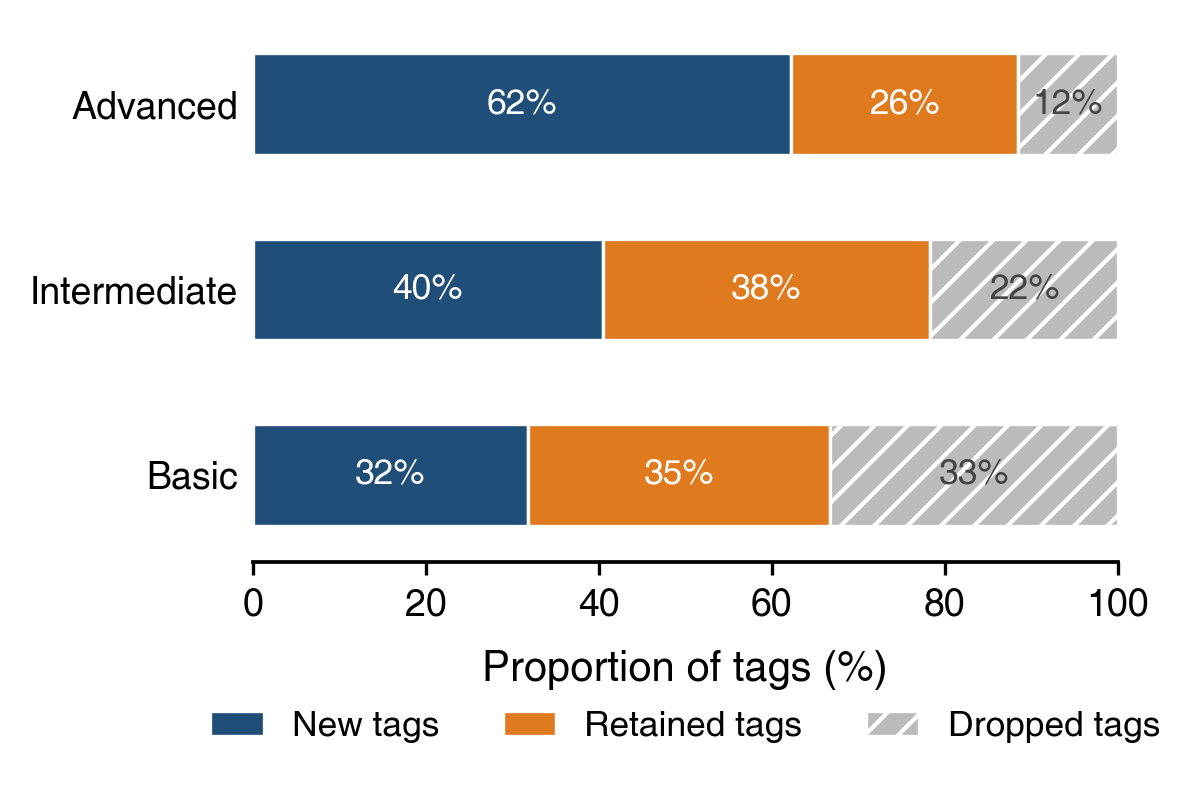

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

PALETTE = {
    'primary': '#1f4e79',   # New tags (생성)
    'accent':  '#E07A1F',   # Retained tags (유지)
    'neutral': '#BBBBBB',   # Dropped tags (사라짐)
}

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

# ═══════════════════════════════════════════
# 데이터 (본인 데이터로 교체)
# ═══════════════════════════════════════════
labels = ['Basic', 'Intermediate', 'Advanced']
groups = ['New tags', 'Retained tags', 'Dropped tags']
colors = [PALETTE['primary'], PALETTE['accent'], PALETTE['neutral']]
hatches = [None, None, '///']   # Dropped만 빗금

# (category × group) — 행: Basic/Intermediate/Advanced
data = np.array([
    list(get_proportion(basic_result_df)['proportion'].values()),   # Basic: new, retained, dropped
    list(get_proportion(inter_result_df)['proportion'].values()),   # Intermediate
    list(get_proportion(adv_result_df)['proportion'].values()),   # Advanced
])

if data.sum(axis=1).mean() < 2:
    data = data * 100   # % 변환

# ═══════════════════════════════════════════
# 가로 stacked bar
# ═══════════════════════════════════════════
y = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(4, 2.8), dpi=300)

left = np.zeros(len(labels))
for i, (group, color, hatch) in enumerate(zip(groups, colors, hatches)):
    bars = ax.barh(y, data[:, i], 0.55, left=left,
                   color=color, edgecolor='white', linewidth=0.8,
                   hatch=hatch, label=group)
    # 값 표시 (라벨이 들어갈 만큼 segment가 큰 경우만)
    for j, bar in enumerate(bars):
        w = bar.get_width()
        if w > 8:
            text_color = '#444' if color == PALETTE['neutral'] else 'white'
            ax.text(left[j] + w/2, bar.get_y() + bar.get_height()/2,
                    f'{w:.0f}%', ha='center', va='center',
                    fontsize=8.5,
                    color=text_color,
                    fontweight='bold')
    left += data[:, i]

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Proportion of tags (%)', fontsize=10, labelpad=6)
ax.set_xlim(0, 100)

ax.tick_params(axis='both', labelsize=9, width=0.8, length=3)
ax.tick_params(axis='y', length=0)   # y tick 라인 제거 (라벨만)

for s in ['top', 'right']: ax.spines[s].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(0.9)
ax.spines['bottom'].set_position(('outward', 3))

ax.grid(False)

# 범례 — 그래프 아래 가로로 (가로 막대에 자연스러움)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25),
          ncol=3, frameon=False, fontsize=8.5,
          handlelength=1.5, columnspacing=1.8)

plt.tight_layout()
plt.savefig('tag_composition.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [41]:
get_proportion(adv_result_df)

{'proportion': {'new': 62.222741069343925,
  'left': 26.219939294886764,
  'gone': 11.557319635769321},
 'tag_list': {'new': array(['.net', '.net-assembly', '2captcha', ..., 'zsh', 'zstd', 'zugferd'],
        shape=(2665,), dtype='<U35'),
  'left': ['machine-learning',
   'autodesk-forge',
   'coremltools',
   'timescaledb',
   'snakemake',
   'mininet',
   'scipy.stats',
   'ruby',
   'web3py',
   'gdal',
   'encode',
   'bytecode',
   'threadpool',
   'lark-parser',
   'apache-beam-io',
   'video-streaming',
   'torchvision',
   'github',
   'reverse',
   'raspberry-pi',
   'django-views',
   'pca',
   'pipeline',
   'bluetooth-lowenergy',
   'py2app',
   'model',
   'symbolic-math',
   'class',
   'hook',
   'tensorflow-federated',
   'code-coverage',
   'asgi',
   'post-processing',
   'pyparsing',
   'lstm',
   'subprocess',
   'pyvista',
   'pyscript',
   'multiple-inheritance',
   'qr-code',
   'pycryptodome',
   'nested',
   'ffmpeg',
   'spline',
   'containers',
   'hyperpara

In [42]:
result_df['top_yn'] = np.where(result_df['tag'].isin(top_list), 1, 0)
result_df['mid_yn'] = np.where(result_df['tag'].isin(mid_list), 1, 0)
result_df['bot_yn'] = np.where(result_df['tag'].isin(bot_list), 1, 0)

In [43]:
result_df['top_pct'] = result_df['top_yn'] * result_df['pct']
result_df['mid_pct'] = result_df['mid_yn'] * result_df['pct']
result_df['bot_pct'] = result_df['bot_yn'] * result_df['pct']

In [44]:
bf_df = result_df[result_df['cdate'] < "2022-11-30"]
af_df = result_df[result_df['cdate'] >= "2022-11-30"]

In [45]:
bf_df

,cdate,id,tag,cnt,tot_cnt,pct,creationdate,result,top_yn,mid_yn,bot_yn,top_pct,mid_pct,bot_pct
0,2021-06-08,67891947,pandas,1,3,0.333333,2021-06-08,<Difficulty Level>0,1,0,0,0.333333,0.000000,0.0
1,2021-06-08,67891947,python-requests,1,3,0.333333,2021-06-08,<Difficulty Level>0,1,0,0,0.333333,0.000000,0.0
2,2021-06-08,67891947,edamam-api,1,3,0.333333,2021-06-08,<Difficulty Level>0,0,1,0,0.000000,0.333333,0.0
3,2021-06-08,67892569,pandas,1,3,0.333333,2021-06-08,<Difficulty Level>1,1,0,0,0.333333,0.000000,0.0
4,2021-06-08,67892569,dataframe,1,3,0.333333,2021-06-08,<Difficulty Level>1,1,0,0,0.333333,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77455,2022-08-17,73394610,django-models,1,3,0.333333,2022-08-17,<Difficulty Level>1,1,0,0,0.333333,0.000000,0.0
77456,2022-08-17,73394610,relationship,1,3,0.333333,2022-08-17,<Difficulty Level>1,0,1,0,0.000000,0.333333,0.0
77457,2022-08-17,73394806,string,1,3,0.333333,2022-08-17,<Difficulty Level>0,1,0,0,0.333333,0.000000,0.0
77458,2022-08-17,73394806,dataframe,1,3,0.333333,2022-08-17,<Difficulty Level>0,1,0,0,0.333333,0.000000,0.0


In [46]:
bf_diff_popularity = bf_df.groupby(['result']).sum()[['top_pct', 'mid_pct', 'bot_pct']].reset_index()

In [47]:
af_diff_popularity = af_df.groupby(['result']).sum()[['top_pct', 'mid_pct', 'bot_pct']].reset_index()

In [48]:
bf_diff_popularity_proportion = bf_diff_popularity.loc[:, ['top_pct', 'mid_pct', 'bot_pct']]/bf_diff_popularity.loc[:, ['top_pct', 'mid_pct', 'bot_pct']].sum()*100
af_diff_popularity_proportion = af_diff_popularity.loc[:, ['top_pct', 'mid_pct', 'bot_pct']]/af_diff_popularity.loc[:, ['top_pct', 'mid_pct', 'bot_pct']].sum()*100

In [49]:
bf_diff_popularity_proportion

,top_pct,mid_pct,bot_pct
0,33.016795,22.010644,13.280600
1,55.401929,53.879205,50.749376
2,11.581276,24.110151,35.970025


In [50]:
af_diff_popularity_proportion

,top_pct,mid_pct,bot_pct
0,18.163206,11.938296,10.612245
1,52.509157,44.352783,42.734694
2,29.327637,43.708920,46.653061


In [51]:
bf_diff_popularity_proportion = bf_diff_popularity.loc[:, ['top_pct', 'mid_pct', 'bot_pct']]/bf_diff_popularity.loc[:, ['top_pct', 'mid_pct', 'bot_pct']].sum()*100
af_diff_popularity_proportion = af_diff_popularity.loc[:, ['top_pct', 'mid_pct', 'bot_pct']]/af_diff_popularity.loc[:, ['top_pct', 'mid_pct', 'bot_pct']].sum()*100

In [52]:
bf_diff_popularity_proportion

,top_pct,mid_pct,bot_pct
0,33.016795,22.010644,13.280600
1,55.401929,53.879205,50.749376
2,11.581276,24.110151,35.970025


In [53]:
bf_diff_popularity_proportion.loc[:, 'top_pct'].values

array([33.0167948 , 55.40192949, 11.58127571])

<BarContainer object of 3 artists>
<BarContainer object of 3 artists>
<BarContainer object of 3 artists>


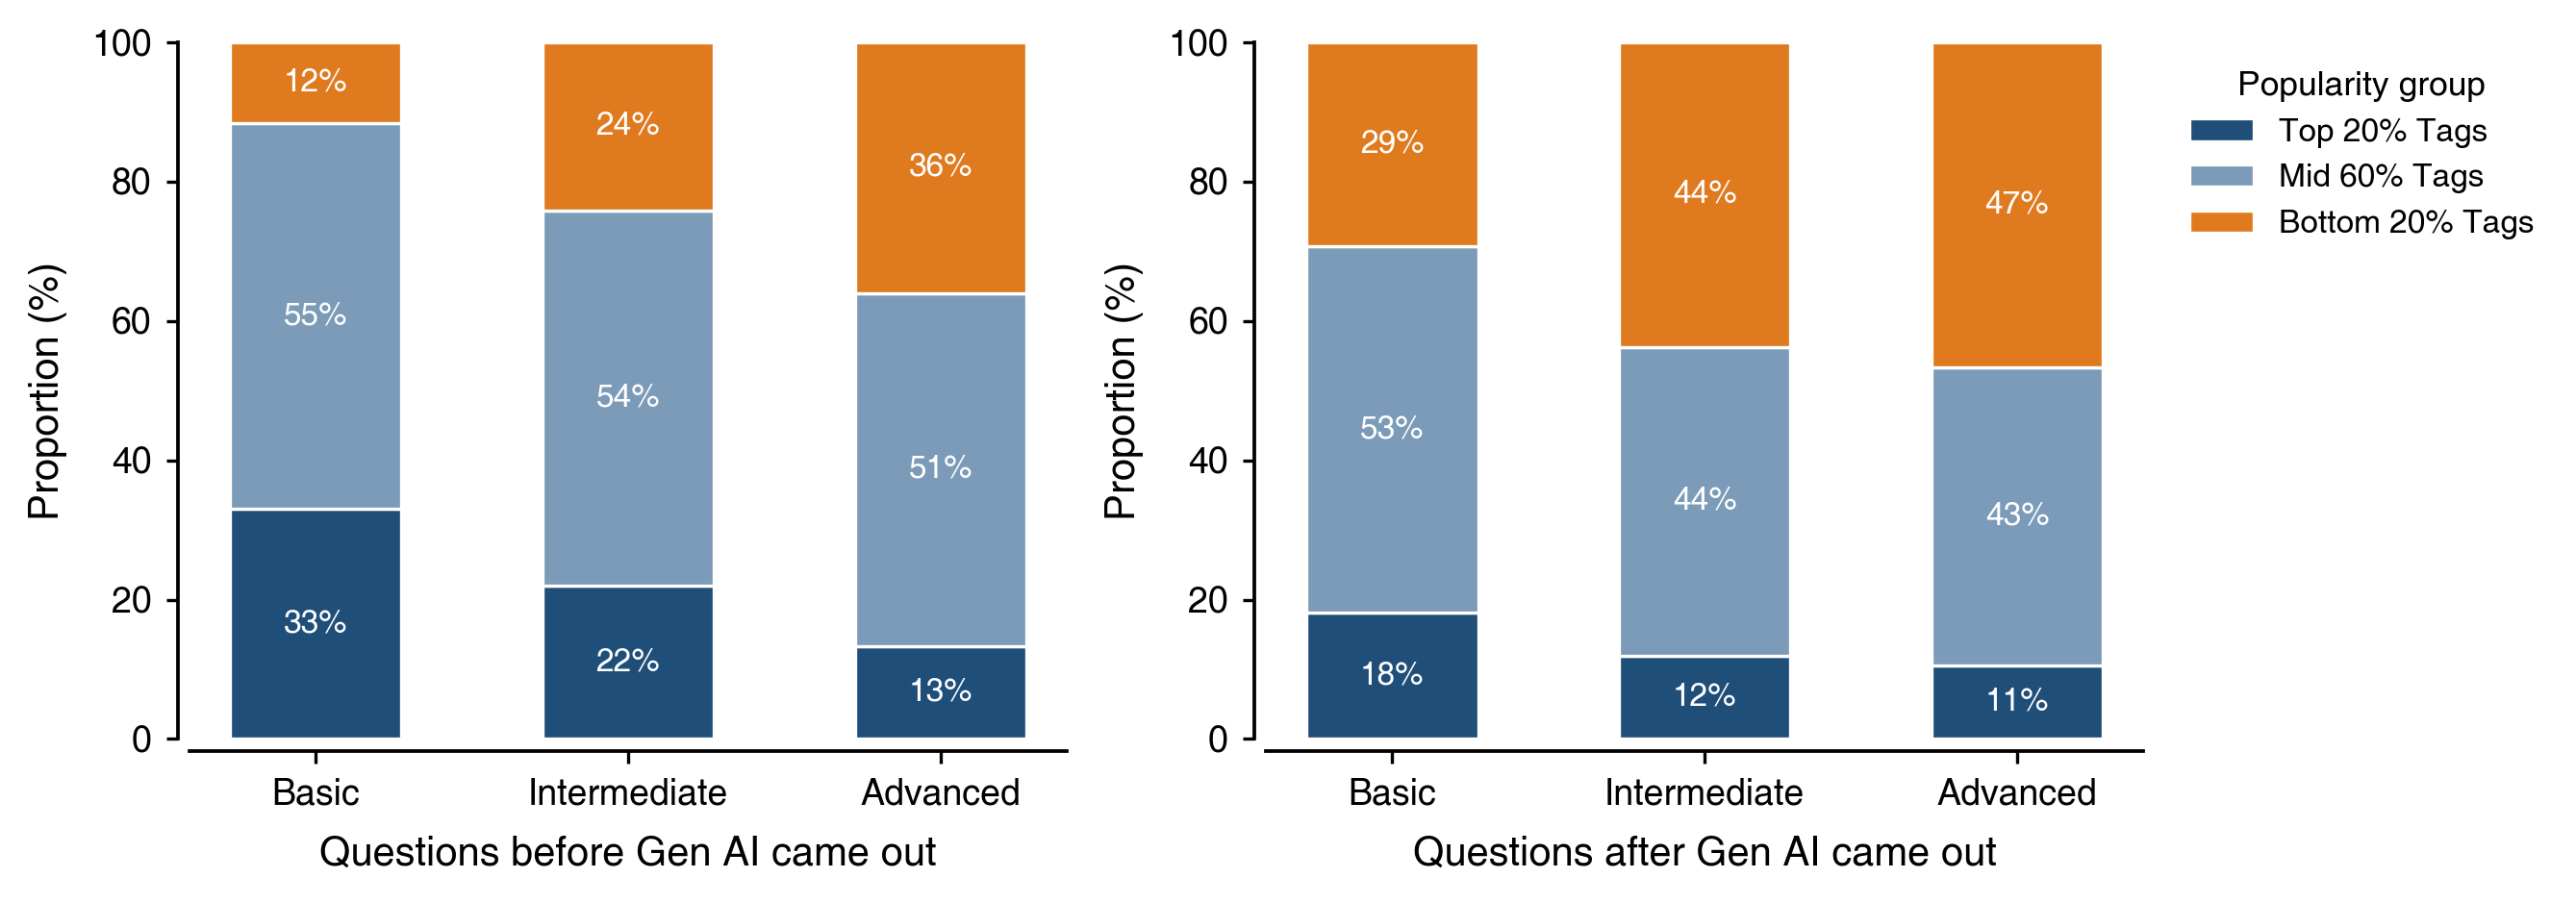

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

PALETTE = {
    'primary': '#1f4e79',
    'mid':     '#7B9BB8',
    'accent':  '#E07A1F',
}

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

# ═══════════════════════════════════════════
# 데이터 준비
# ═══════════════════════════════════════════
labels = ['Basic', 'Intermediate', 'Advanced']
groups = ['Top 20% Tags', 'Mid 60% Tags', 'Bottom 20% Tags']
colors = [PALETTE['primary'], PALETTE['mid'], PALETTE['accent']]

data1 = np.array([
    bf_diff_popularity_proportion.loc[:, 'top_pct'].values,
    bf_diff_popularity_proportion.loc[:, 'mid_pct'].values,
    bf_diff_popularity_proportion.loc[:, 'bot_pct'].values,
], dtype=float)


data2 = np.array([
    af_diff_popularity_proportion.loc[:, 'top_pct'].values,
    af_diff_popularity_proportion.loc[:, 'mid_pct'].values,
    af_diff_popularity_proportion.loc[:, 'bot_pct'].values,
], dtype=float)

# 0~1 스케일이면 % 변환
if data.sum(axis=1).mean() < 2:
    data = data * 100

# ═══════════════════════════════════════════
# Plot
# ═══════════════════════════════════════════
x = np.arange(len(labels))
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2), dpi=300)

bottom = np.zeros(len(labels))
for i, (group, color) in enumerate(zip(groups, colors)):
    bars = ax[0].bar(x, data1[:, i], 0.55, bottom=bottom,
                  color=color, edgecolor='white', linewidth=0.8,
                  label=group)
    # 값 표시
    for j, bar in enumerate(bars):
        h = bar.get_height()
        if h > 5:
            ax[0].text(bar.get_x() + bar.get_width()/2,
                       bottom[j] + h/2,
                       f'{h:.0f}%', ha='center', va='center',
                       fontsize=8, color='white', fontweight='bold')
    bottom += data1[:, i]

ax[0].set_xticks(x)
ax[0].set_xticklabels(labels, fontsize=9.5)
ax[0].set_xlabel('Questions before Gen AI came out', fontsize=10, labelpad=6)
ax[0].set_ylabel('Proportion (%)',   fontsize=10, labelpad=6)
ax[0].set_ylim(0, 100)

ax[0].tick_params(axis='both', labelsize=9, width=0.8, length=3)

for s in ['top', 'right']: ax[0].spines[s].set_visible(False)
ax[0].spines['left'].set_linewidth(0.9)
ax[0].spines['bottom'].set_linewidth(0.9)
ax[0].spines['left'].set_position(('outward', 3))
ax[0].spines['bottom'].set_position(('outward', 3))

ax[0].grid(False)


x = np.arange(len(labels))
bottom = np.zeros(len(labels))
for i, (group, color) in enumerate(zip(groups, colors)):
    bars = ax[1].bar(x, data2[:, i], 0.55, bottom=bottom,
                  color=color, edgecolor='white', linewidth=0.8,
                  label=group)
    print(bars)
    # 값 표시

    for j, bar in enumerate(bars):
        h = bar.get_height()
        if h > 5:
            ax[1].text(bar.get_x() + bar.get_width()/2,
                       bottom[j] + h/2,
                       f'{h:.0f}%', ha='center', va='center',
                       fontsize=8, color='white', fontweight='bold')
    bottom += data2[:, i]

ax[1].set_xticks(x)
ax[1].set_xticklabels(labels, fontsize=9.5)
ax[1].set_xlabel('Questions after Gen AI came out', fontsize=10, labelpad=6)
ax[1].set_ylabel('Proportion (%)',   fontsize=10, labelpad=6)
ax[1].set_ylim(0, 100)

ax[1].tick_params(axis='both', labelsize=9, width=0.8, length=3)

for s in ['top', 'right']: ax[1].spines[s].set_visible(False)

ax[1].spines['left'].set_linewidth(0.9)
ax[1].spines['bottom'].set_linewidth(0.9)
ax[1].spines['left'].set_position(('outward', 3))
ax[1].spines['bottom'].set_position(('outward', 3))

ax[1].grid(False)

ax[1].legend(title='Popularity group', loc='upper left',
          bbox_to_anchor=(1.02, 1.0),
          fontsize=8, title_fontsize=8.5, frameon=False)

plt.tight_layout()
plt.savefig('popularity_by_difficulty_stacked.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

In [55]:
bf_diff_popularity['tot'] = bf_diff_popularity[['top_pct', 'mid_pct', 'bot_pct']].sum(axis = 1)
af_diff_popularity['tot'] = af_diff_popularity[['top_pct', 'mid_pct', 'bot_pct']].sum(axis = 1)

In [56]:
bf_diff_popularity['top_proportion'] = bf_diff_popularity['top_pct']/bf_diff_popularity['tot']*100
bf_diff_popularity['mid_proportion'] = bf_diff_popularity['mid_pct']/bf_diff_popularity['tot']*100
bf_diff_popularity['bot_proportion'] = bf_diff_popularity['bot_pct']/bf_diff_popularity['tot']*100

In [57]:
af_diff_popularity['top_proportion'] = af_diff_popularity['top_pct']/af_diff_popularity['tot']*100
af_diff_popularity['mid_proportion'] = af_diff_popularity['mid_pct']/af_diff_popularity['tot']*100
af_diff_popularity['bot_proportion'] = af_diff_popularity['bot_pct']/af_diff_popularity['tot']*100

In [58]:
af_df['proportion'] = af_df['pct']/af_df['pct'].sum()*100
bf_df['proportion'] = bf_df['pct']/bf_df['pct'].sum()*100

/tmp/ipykernel_2310508/3047503368.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  af_df['proportion'] = af_df['pct']/af_df['pct'].sum()*100
/tmp/ipykernel_2310508/3047503368.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bf_df['proportion'] = bf_df['pct']/bf_df['pct'].sum()*100


In [59]:
af_top_df = af_df[af_df['top_yn'] == 1].groupby(['tag'])['proportion'].sum().reset_index().sort_values(by = ['proportion'], ascending=False).rename(columns={'proportion': 'af_top_pct'})
af_bot_df = af_df[af_df['bot_yn'] == 1].groupby(['tag'])['proportion'].sum().reset_index().sort_values(by = ['proportion'], ascending=False).rename(columns={'proportion': 'af_bot_pct'}) 
# 

In [60]:
bf_top_df = bf_df[bf_df['top_yn'] == 1].groupby(['tag'])['proportion'].sum().reset_index().sort_values(by = ['proportion'], ascending=False).rename(columns={'proportion': 'bf_top_pct'})
bf_bot_df = bf_df[bf_df['bot_yn'] == 1].groupby(['tag'])['proportion'].sum().reset_index().sort_values(by = ['proportion'], ascending=False).rename(columns={'proportion': 'bf_bot_pct'})

In [61]:
bf_bot_df['bf_bot_pct']

643    0.002474
520    0.002474
641    0.002474
640    0.002474
282    0.002474
         ...   
268    0.001856
269    0.001856
270    0.001856
273    0.001856
259    0.001856
Name: bf_bot_pct, Length: 778, dtype: float64

In [62]:
bot_bf_af_pct = pd.merge(af_bot_df, bf_bot_df, on='tag')
top_bf_af_pct = pd.merge(af_top_df, bf_top_df, on='tag')

In [63]:
bot_bf_af_pct

,tag,af_bot_pct,bf_bot_pct
0,huggingface,0.085844,0.001856
1,sqlmodel,0.039453,0.001856
2,openai-whisper,0.038153,0.001856
3,nicegui,0.033817,0.001856
4,google-oauth,0.030782,0.002474
...,...,...,...
380,solid-state-drive,0.001301,0.001856
381,spectral-density,0.001301,0.001856
382,sql-update,0.001301,0.001856
383,steam-web-api,0.001301,0.001856


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


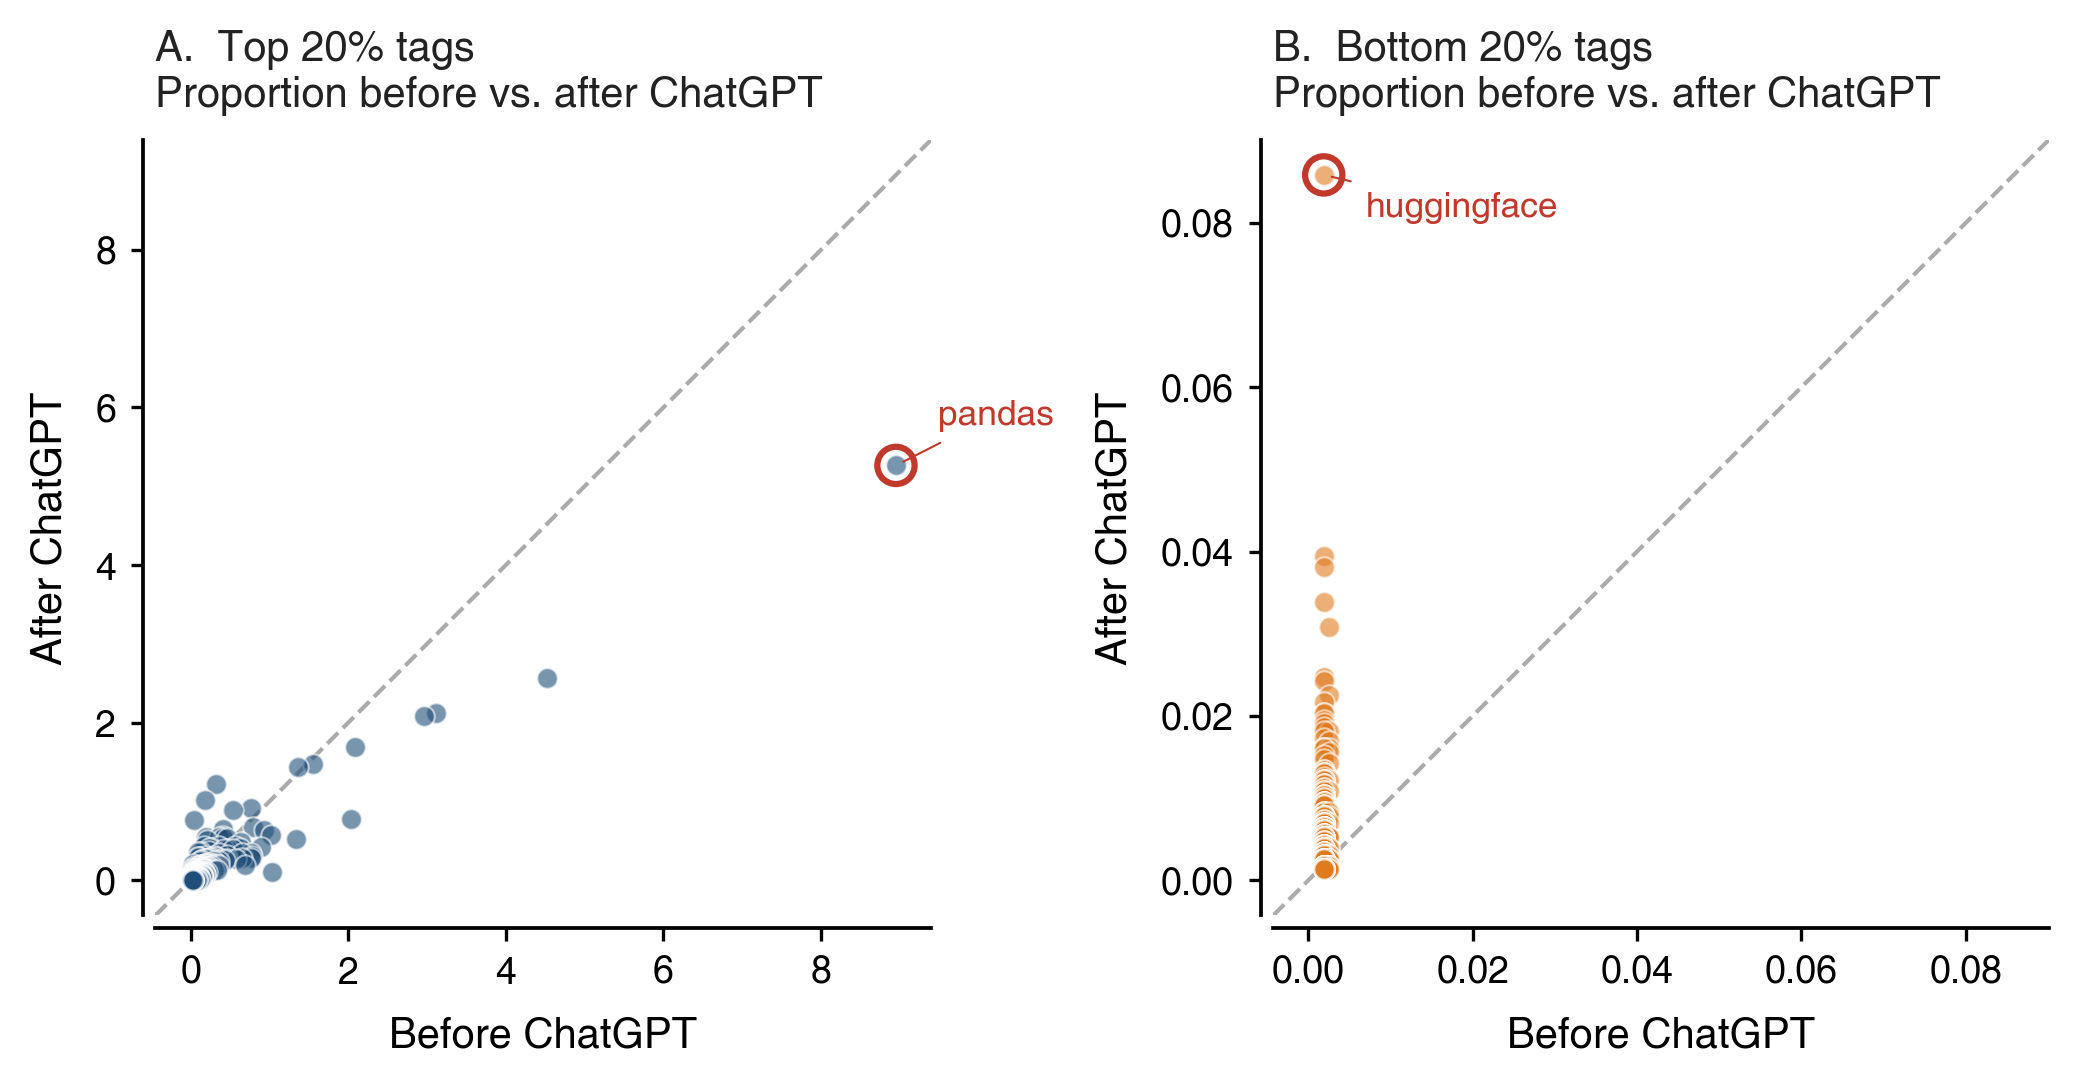

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

PALETTE = {
    'primary': '#1f4e79',   # Top
    'accent':  '#E07A1F',   # Bottom
    'event':   '#C0392B',
    'neutral': '#888888',
}

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

# ═══════════════════════════════════════════
# 패널 그리기 함수
# ═══════════════════════════════════════════
def plot_bf_af(ax, x, y, color, group_name, panel_label,
               labels=None, n_highlight=1):
    """
    labels: 각 점의 이름 (예: 태그명, 주차)
    n_highlight: 강조할 점 개수 (변화량 절댓값 기준 상위 N개)
    """
    x = np.asarray(x)
    y = np.asarray(y)

    all_vals = np.concatenate([x, y])
    lo = min(0, all_vals.min())
    hi = all_vals.max()
    pad = (hi - lo) * 0.05
    lim = (lo - pad, hi + pad)

    # y=x 대각선
    ax.plot(lim, lim, ls='--', color=PALETTE['neutral'], lw=1.0,
            alpha=0.7, zorder=1)

    # 일반 산점도
    ax.scatter(x, y, s=24, color=color, alpha=0.6,
               edgecolor='white', linewidth=0.5, zorder=3)

    # ★ 변화량(절댓값) 가장 큰 점들 찾기
    deviation = y - x
    top_idx = np.argsort(np.abs(deviation))[-n_highlight:]

    # 강조 + 라벨
    for idx in top_idx:
        ax.scatter(x[idx], y[idx], s=80,
                   facecolor='none', edgecolor=PALETTE['event'],
                   linewidth=1.5, zorder=4)

        label_text = str(labels[idx]) if labels is not None else f'idx={idx}'

        # 라벨을 점의 변화 방향과 반대쪽으로 배치 (가독성)
        if deviation[idx] > 0:   # 위로 갔으면 라벨은 오른쪽 아래
            xytext = (10, -10)
        else:                     # 아래로 갔으면 라벨은 오른쪽 위
            xytext = (10, 10)

        ax.annotate(label_text,
                    xy=(x[idx], y[idx]),
                    xytext=xytext, textcoords='offset points',
                    fontsize=8.5, color=PALETTE['event'],
                    fontweight='bold',
                    arrowprops=dict(arrowstyle='-',
                                    color=PALETTE['event'], lw=0.5))

    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect('equal')

    ax.set_title(f'{panel_label}.  {group_name}\nProportion before vs. after ChatGPT',
                 fontsize=10, loc='left', pad=8, color='#222')
    ax.set_xlabel('Before ChatGPT', fontsize=10, labelpad=6)
    ax.set_ylabel('After ChatGPT',  fontsize=10, labelpad=6)
    ax.tick_params(axis='both', labelsize=9, width=0.8, length=3)

    for s in ['top', 'right']: ax.spines[s].set_visible(False)
    ax.spines['left'].set_linewidth(0.9)
    ax.spines['bottom'].set_linewidth(0.9)
    ax.spines['left'].set_position(('outward', 3))
    ax.spines['bottom'].set_position(('outward', 3))
    ax.grid(False)

    # ax.text(0.97, 0.97, 'increased\nafter', transform=ax.transAxes,
    #         fontsize=7.5, color=PALETTE['neutral'], ha='right', va='top',
    #         style='italic', alpha=0.8)
    # ax.text(0.03, 0.03, 'decreased\nafter', transform=ax.transAxes,
    #         fontsize=7.5, color=PALETTE['neutral'], ha='left', va='bottom',
    #         style='italic', alpha=0.8)

    ax.legend(loc='upper left', frameon=False, fontsize=8,
              handlelength=1.5, borderpad=0.3)

# ═══════════════════════════════════════════
# Figure
# ═══════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.6), dpi=300)

plot_bf_af(axes[0],
           top_bf_af_pct['bf_top_pct'],
           top_bf_af_pct['af_top_pct'],
           color=PALETTE['primary'],
           group_name='Top 20% tags',
           panel_label='A',
           labels=top_bf_af_pct['tag'].values,   # ← 본인 데이터의 식별 컬럼
           n_highlight=1)

plot_bf_af(axes[1],
           bot_bf_af_pct['bf_bot_pct'],
           bot_bf_af_pct['af_bot_pct'],
           color=PALETTE['accent'],
           group_name='Bottom 20% tags',
           panel_label='B',
           labels=bot_bf_af_pct['tag'].values,
           n_highlight=1)

plt.tight_layout()
plt.savefig('tags_bf_af_scatter.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()